<a href="https://colab.research.google.com/github/yagizcakir/DSA210-TERM-PROJECT/blob/main/notebook/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Libraries are ready ✓")

Libraries are ready ✓


In [52]:
# Load datasets
df = pd.read_csv('England_2013_2024.csv')
df_s = pd.read_csv('standings_by_date_2013_2024.csv')

# Fix date columns
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df_s['date'] = pd.to_datetime(df_s['date'])

# Fix goal columns to integer
df['FTH Goals'] = df['FTH Goals'].astype(int)
df['FTA Goals'] = df['FTA Goals'].astype(int)

print(f"Total matches: {len(df)}")
print(f"Seasons: {sorted(df['Season'].unique())}")
print(f"Standings rows: {len(df_s)}")
print(f"Standings columns: {list(df_s.columns)}")
print(f"\nMissing values in match data:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Total matches: 4180
Seasons: ['2013/14', '2014/15', '2015/16', '2016/17', '2017/18', '2018/19', '2019/20', '2020/21', '2021/22', '2022/23', '2023/24']
Standings rows: 24400
Standings columns: ['season', 'date', 'position', 'team', 'played', 'won', 'draw', 'lost', 'goals_for', 'goals_against', 'goal_difference', 'points']

Missing values in match data:
Series([], dtype: int64)


In [53]:
# General statistics
print("=== MATCH DATA GENERAL STATISTICS ===")
print(df[['FTH Goals', 'FTA Goals', 'H Shots', 'A Shots',
          'H Yellow', 'A Yellow']].describe().round(2))

print("\n=== STANDINGS DATA GENERAL STATISTICS ===")
print(df_s[['position', 'played', 'points',
            'goals_for', 'goals_against', 'goal_difference']].describe().round(2))

=== MATCH DATA GENERAL STATISTICS ===
       FTH Goals  FTA Goals  H Shots  A Shots  H Yellow  A Yellow
count    4180.00    4180.00  4180.00  4180.00   4180.00   4180.00
mean        1.55       1.24    14.09    11.46      1.59      1.79
std         1.33       1.20     5.74     4.97      1.25      1.29
min         0.00       0.00     0.00     0.00      0.00      0.00
25%         1.00       0.00    10.00     8.00      1.00      1.00
50%         1.00       1.00    13.00    11.00      1.00      2.00
75%         2.00       2.00    17.00    15.00      2.00      3.00
max         9.00       9.00    43.00    31.00      7.00      9.00

=== STANDINGS DATA GENERAL STATISTICS ===
       position    played    points  goals_for  goals_against  goal_difference
count  24400.00  24400.00  24400.00   24400.00       24400.00         24400.00
mean      10.50     19.79     27.33      27.50          27.50             0.00
std        5.77     11.07     18.93      18.82          17.48            17.24
min      

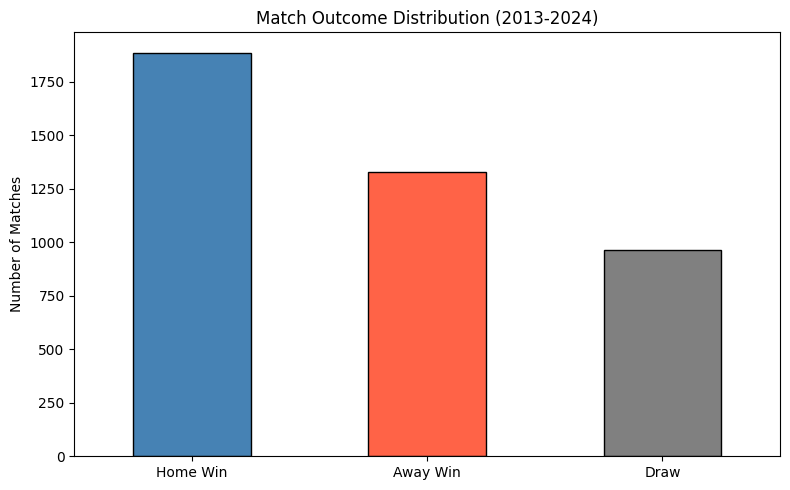

In [54]:
# Win rate distribution
result_counts = df['FT Result'].value_counts()
labels = {'H': 'Home Win', 'A': 'Away Win', 'D': 'Draw'}
result_counts.index = [labels[i] for i in result_counts.index]

plt.figure(figsize=(8, 5))
result_counts.plot(kind='bar', color=['steelblue', 'tomato', 'gray'], edgecolor='black')
plt.title('Match Outcome Distribution (2013-2024)')
plt.ylabel('Number of Matches')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

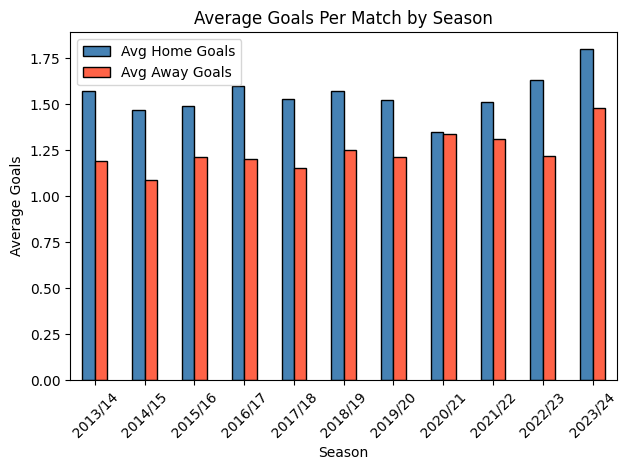

In [55]:
# Average goals per season
goals_by_season = df.groupby('Season')[['FTH Goals', 'FTA Goals']].mean().round(2)
goals_by_season.columns = ['Avg Home Goals', 'Avg Away Goals']

plt.figure(figsize=(12, 5))
goals_by_season.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Average Goals Per Match by Season')
plt.ylabel('Average Goals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

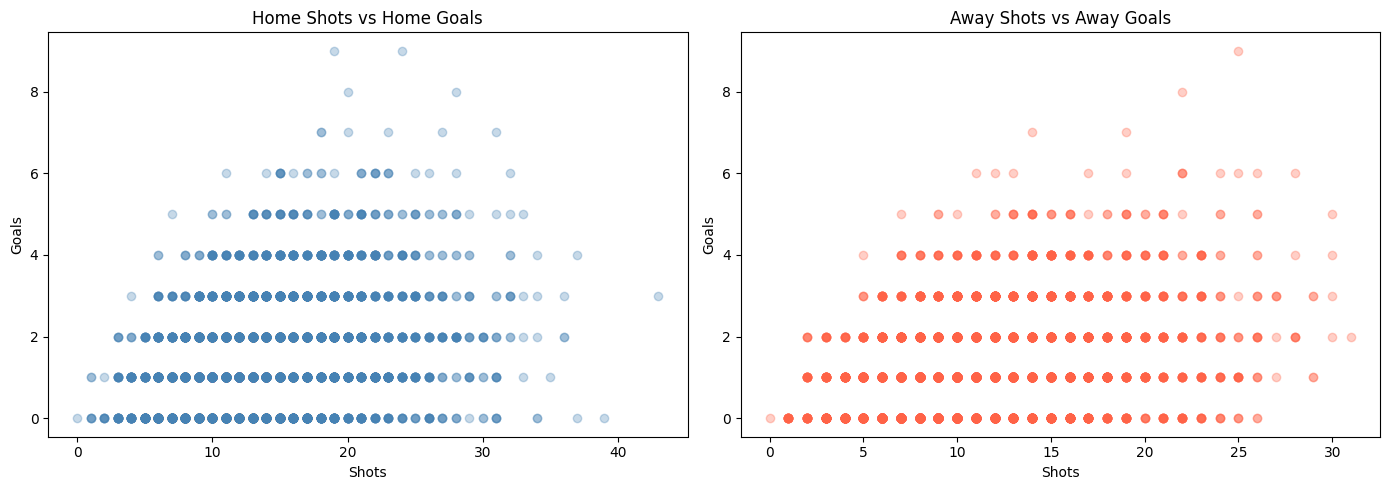

In [56]:
# Shots vs Goals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['H Shots'], df['FTH Goals'], alpha=0.3, color='steelblue')
axes[0].set_title('Home Shots vs Home Goals')
axes[0].set_xlabel('Shots')
axes[0].set_ylabel('Goals')

axes[1].scatter(df['A Shots'], df['FTA Goals'], alpha=0.3, color='tomato')
axes[1].set_title('Away Shots vs Away Goals')
axes[1].set_xlabel('Shots')
axes[1].set_ylabel('Goals')

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

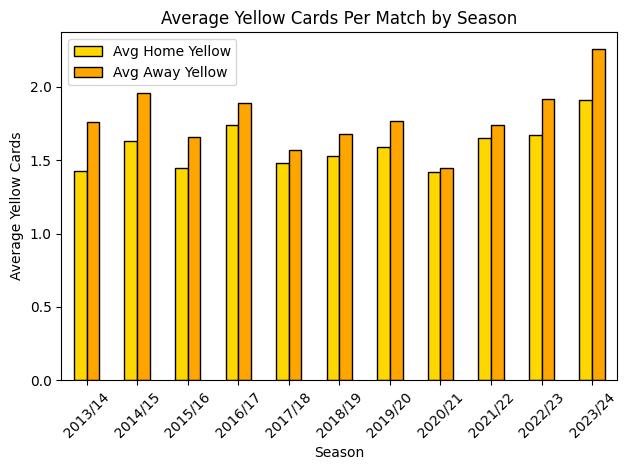

In [57]:
# Yellow cards per season
cards = df.groupby('Season')[['H Yellow', 'A Yellow']].mean().round(2)
cards.columns = ['Avg Home Yellow', 'Avg Away Yellow']

plt.figure(figsize=(12, 5))
cards.plot(kind='bar', color=['gold', 'orange'], edgecolor='black')
plt.title('Average Yellow Cards Per Match by Season')
plt.ylabel('Average Yellow Cards')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

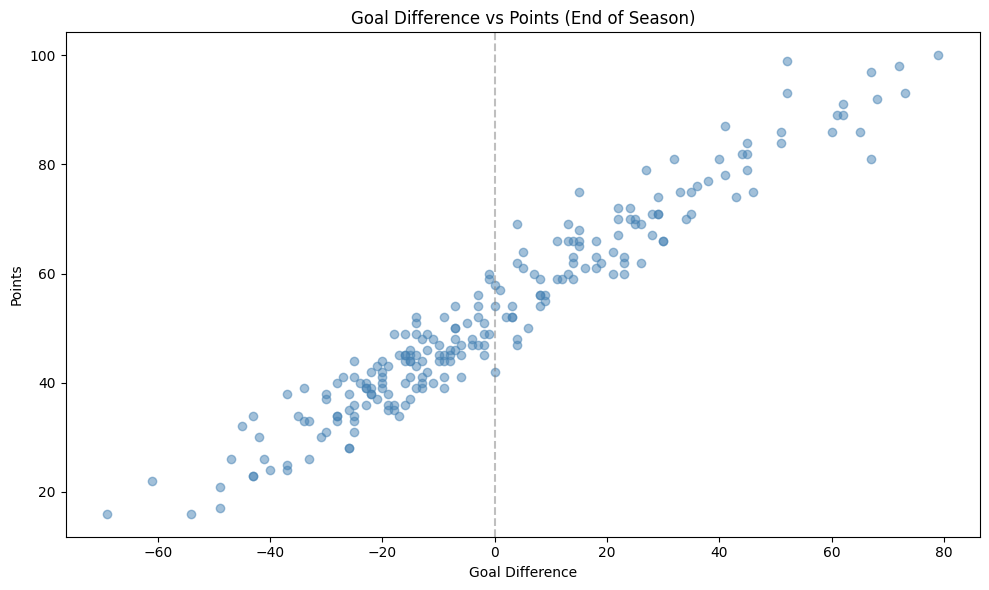

In [58]:
# Points vs Goal Difference
# Get end of season standings (last date per team per season)
season_end = df_s.groupby(['season', 'team']).last().reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(season_end['goal_difference'], season_end['points'], alpha=0.5, color='steelblue')
plt.title('Goal Difference vs Points (End of Season)')
plt.xlabel('Goal Difference')
plt.ylabel('Points')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

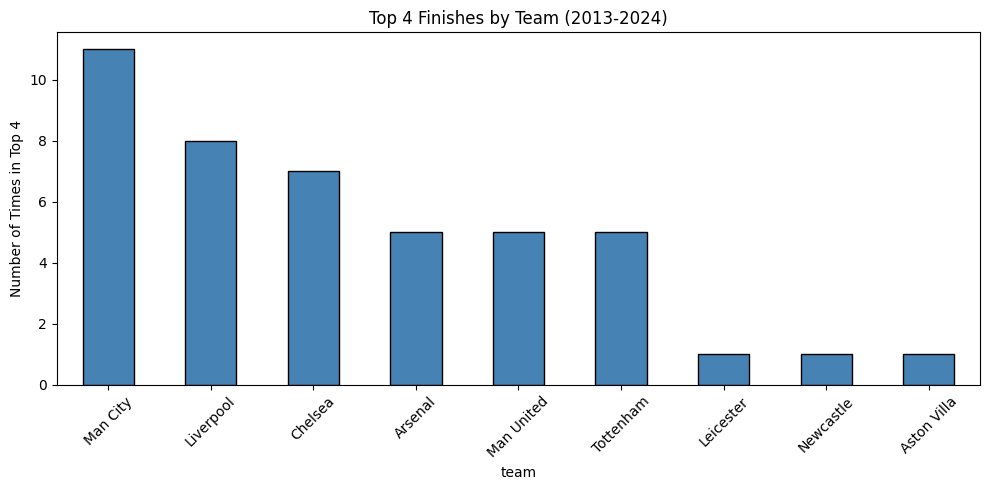

In [59]:
# Which teams finish in top 4 most often?
season_end = df_s.groupby(['season', 'team']).last().reset_index()
top4 = season_end[season_end['position'] <= 4]
top4_counts = top4['team'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top4_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 4 Finishes by Team (2013-2024)')
plt.ylabel('Number of Times in Top 4')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
# H1: Home Advantage - Do home teams score more?
# H0: No difference between home and away goals
# H1: Home teams score significantly more goals

home_goals = df['FTH Goals']
away_goals = df['FTA Goals']

t_stat, p_value = stats.ttest_ind(home_goals, away_goals)

print("=== H1: Home vs Away Goals ===")
print(f"Home goals mean: {home_goals.mean():.3f}")
print(f"Away goals mean: {away_goals.mean():.3f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.5f}")
if p_value < 0.05:
    print("Result: REJECT H0 → Home teams score significantly more goals ✓")
else:
    print("Result: FAIL TO REJECT H0 → No significant difference")

=== H1: Home vs Away Goals ===
Home goals mean: 1.550
Away goals mean: 1.241
T-statistic: 11.184
P-value: 0.00000
Result: REJECT H0 → Home teams score significantly more goals ✓


=== H2: Shots vs Goals Correlation ===
Home - Correlation: 0.312, P-value: 0.00000
Away - Correlation: 0.348, P-value: 0.00000
Home Result: REJECT H0 → Shots significantly correlate with goals ✓
Away Result: REJECT H0 → Shots significantly correlate with goals ✓


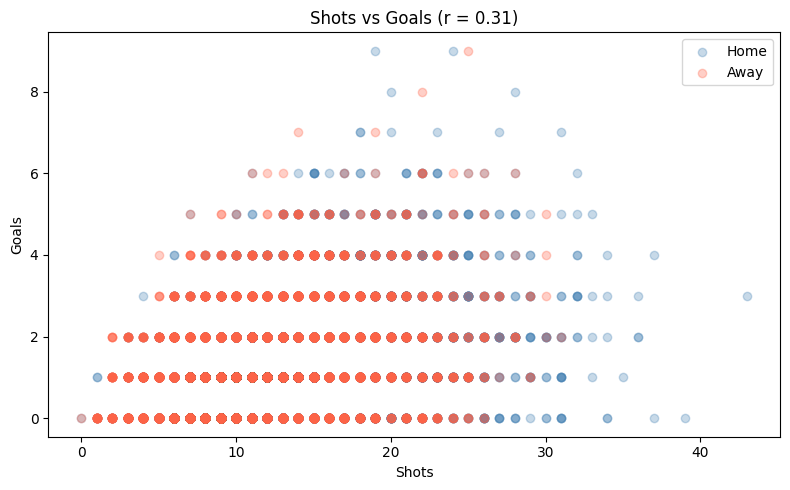

In [61]:
# H2: Does the number of shots correlate with goals scored?
# H0: No correlation between shots and goals
# H1: More shots = more goals (positive correlation)

corr_home, p_home = stats.pearsonr(df['H Shots'], df['FTH Goals'])
corr_away, p_away = stats.pearsonr(df['A Shots'], df['FTA Goals'])

print("=== H2: Shots vs Goals Correlation ===")
print(f"Home - Correlation: {corr_home:.3f}, P-value: {p_home:.5f}")
print(f"Away - Correlation: {corr_away:.3f}, P-value: {p_away:.5f}")

if p_home < 0.05:
    print("Home Result: REJECT H0 → Shots significantly correlate with goals ✓")
if p_away < 0.05:
    print("Away Result: REJECT H0 → Shots significantly correlate with goals ✓")

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(df['H Shots'], df['FTH Goals'], alpha=0.3, color='steelblue', label='Home')
plt.scatter(df['A Shots'], df['FTA Goals'], alpha=0.3, color='tomato', label='Away')
plt.title(f'Shots vs Goals (r = {corr_home:.2f})')
plt.xlabel('Shots')
plt.ylabel('Goals')
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
# H3: Is there a significant relationship between HT result and FT result?
# H0: HT result and FT result are independent
# H1: HT result significantly predicts FT result

contingency_table = pd.crosstab(df['HT Result'], df['FT Result'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("=== H3: Half-Time Result vs Full-Time Result ===")
print(f"\nContingency Table:")
print(contingency_table)
print(f"\nChi-square statistic: {chi2:.3f}")
print(f"P-value: {p_value:.5f}")
print(f"Degrees of freedom: {dof}")
if p_value < 0.05:
    print("Result: REJECT H0 → HT result significantly predicts FT result ✓")
else:
    print("Result: FAIL TO REJECT H0 → No significant relationship")

=== H3: Half-Time Result vs Full-Time Result ===

Contingency Table:
FT Result    A    D     H
HT Result                
A          767  181   109
D          480  582   632
H           82  201  1146

Chi-square statistic: 1720.145
P-value: 0.00000
Degrees of freedom: 4
Result: REJECT H0 → HT result significantly predicts FT result ✓


=== H4: Goal Difference vs Points ===
Correlation: 0.967
P-value: 0.00000
Result: REJECT H0 → Goal difference strongly correlates with points ✓


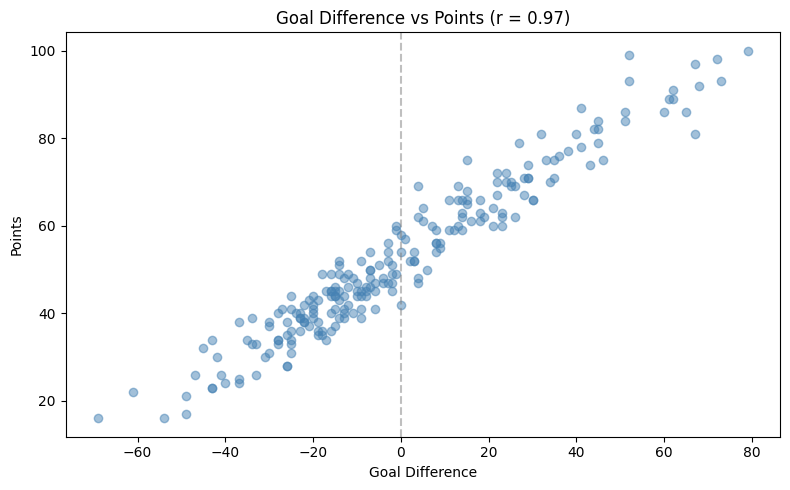

In [63]:
# H4: Is there a significant correlation between goal difference and points?
# H0: No correlation between goal difference and points
# H1: Higher goal difference = more points

season_end = df_s.groupby(['season', 'team']).last().reset_index()

corr, p_value = stats.pearsonr(season_end['goal_difference'], season_end['points'])

print("=== H4: Goal Difference vs Points ===")
print(f"Correlation: {corr:.3f}")
print(f"P-value: {p_value:.5f}")
if p_value < 0.05:
    print("Result: REJECT H0 → Goal difference strongly correlates with points ✓")

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(season_end['goal_difference'], season_end['points'], alpha=0.5, color='steelblue')
plt.title(f'Goal Difference vs Points (r = {corr:.2f})')
plt.xlabel('Goal Difference')
plt.ylabel('Points')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [64]:
# H5: Do teams with more yellow cards win less?
# H0: No difference in yellow cards between winners and losers
# H1: Losing teams receive more yellow cards

home_wins = df[df['FT Result'] == 'H']['H Yellow']
home_losses = df[df['FT Result'] == 'A']['H Yellow']

t_stat, p_value = stats.ttest_ind(home_wins, home_losses)

print("=== H5: Yellow Cards vs Match Result ===")
print(f"Avg yellow cards (home wins): {home_wins.mean():.3f}")
print(f"Avg yellow cards (home losses): {home_losses.mean():.3f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.5f}")
if p_value < 0.05:
    print("Result: REJECT H0 → Yellow cards significantly affect match result ✓")
else:
    print("Result: FAIL TO REJECT H0 → No significant difference")

=== H5: Yellow Cards vs Match Result ===
Avg yellow cards (home wins): 1.441
Avg yellow cards (home losses): 1.682
T-statistic: -5.426
P-value: 0.00000
Result: REJECT H0 → Yellow cards significantly affect match result ✓


=== H5: Home Advantage Over Time ===
 Season  home_win_rate
2013/14       0.471053
2014/15       0.452632
2015/16       0.413158
2016/17       0.492105
2017/18       0.455263
2018/19       0.476316
2019/20       0.452632
2020/21       0.378947
2021/22       0.428947
2022/23       0.484211
2023/24       0.460526

Correlation: -0.098
P-value: 0.77476
Result: FAIL TO REJECT H0 → Home advantage has stayed consistent


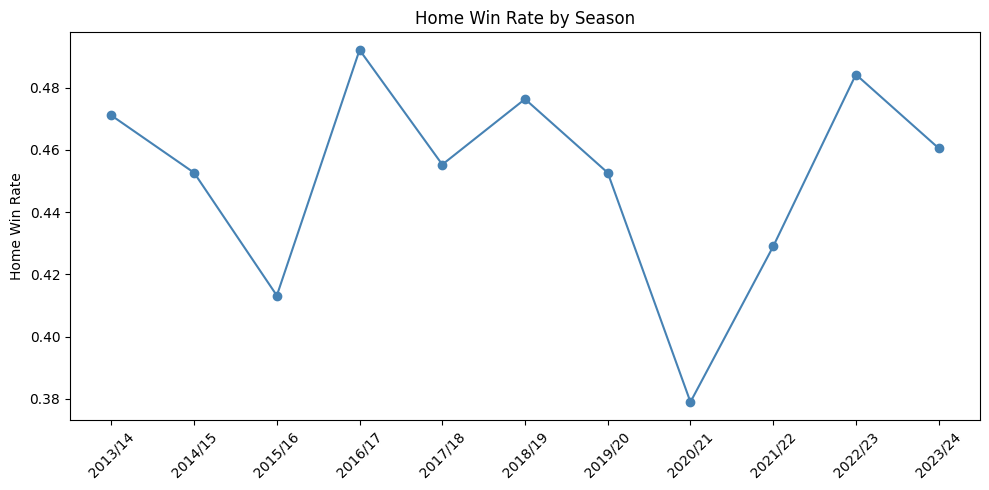

In [68]:
# Home win rate per season — has it decreased over time?
home_win_rate = df.groupby('Season').apply(
    lambda x: (x['FT Result'] == 'H').sum() / len(x),
    include_groups=False
).reset_index()
home_win_rate.columns = ['Season', 'home_win_rate']

# Assign numeric order to seasons
home_win_rate['season_num'] = range(len(home_win_rate))

corr, p_value = stats.pearsonr(home_win_rate['season_num'], home_win_rate['home_win_rate'])

print("=== H5: Home Advantage Over Time ===")
print(home_win_rate[['Season', 'home_win_rate']].to_string(index=False))
print(f"\nCorrelation: {corr:.3f}")
print(f"P-value: {p_value:.5f}")
if p_value < 0.05:
    print("Result: REJECT H0 → Home advantage has significantly changed over time ✓")
else:
    print("Result: FAIL TO REJECT H0 → Home advantage has stayed consistent")

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(home_win_rate['Season'], home_win_rate['home_win_rate'], marker='o', color='steelblue')
plt.title('Home Win Rate by Season')
plt.ylabel('Home Win Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()